# Dibujar la palabra HOPFIELD

Usa el abecedario de `letters.txt` (5×5 con `±1`) para renderizar la palabra **HOPFIELD** letra por letra. Dos versiones:

1. Todo azul (mismo `cmap` para todas).
2. Multicolor (un `cmap` distinto por letra).

In [1]:
import string

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def create_letter_plot(letter, ax, cmap='Blues'):
    p = sns.heatmap(letter, ax=ax, annot=False, cbar=False, cmap=cmap,
                    square=True, linewidth=2, linecolor='black')
    p.xaxis.set_visible(False)
    p.yaxis.set_visible(False)
    return p


def print_letters_line(letters, cmap='Blues', cmaps=None):
    fig, ax = plt.subplots(1, len(letters))
    fig.set_dpi(360)
    if len(letters) == 1:
        ax = [ax]
    if not cmaps:
        cmaps = [cmap] * len(letters)
    if len(cmaps) != len(letters):
        raise Exception('cmap list should be the same length as letters')
    for i, subplot in enumerate(ax):
        create_letter_plot(letters[i].reshape(5, 5), ax=subplot, cmap=cmaps[i])
    plt.show()

In [3]:
with open('letters.txt') as fp:
    letters = {}
    current = np.ones((5, 5)) * -1
    idx = 0
    for line in fp:
        if not line.strip():
            continue
        if line[0] == '=':
            letters[string.ascii_uppercase[len(letters)]] = current
            current = np.ones((5, 5)) * -1
            idx = 0
        else:
            for i, c in enumerate(line.rstrip('\n')):
                if i >= 5:
                    break
                current[idx][i] = 1 if c == '*' else -1
            idx += 1

WORD = 'HOPFIELD'
word_letters = [letters[c] for c in WORD]
print(f'Letras de "{WORD}": {list(WORD)}')

Letras de "HOPFIELD": ['H', 'O', 'P', 'F', 'I', 'E', 'L', 'D']


## Versión 1: todo azul

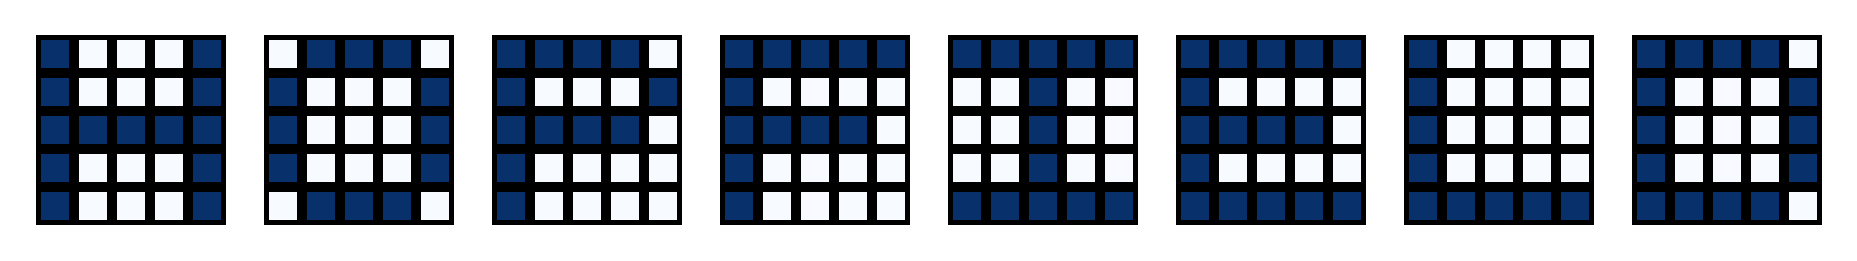

In [4]:
print_letters_line(word_letters, cmap='Blues')

## Versión 2: un color por letra

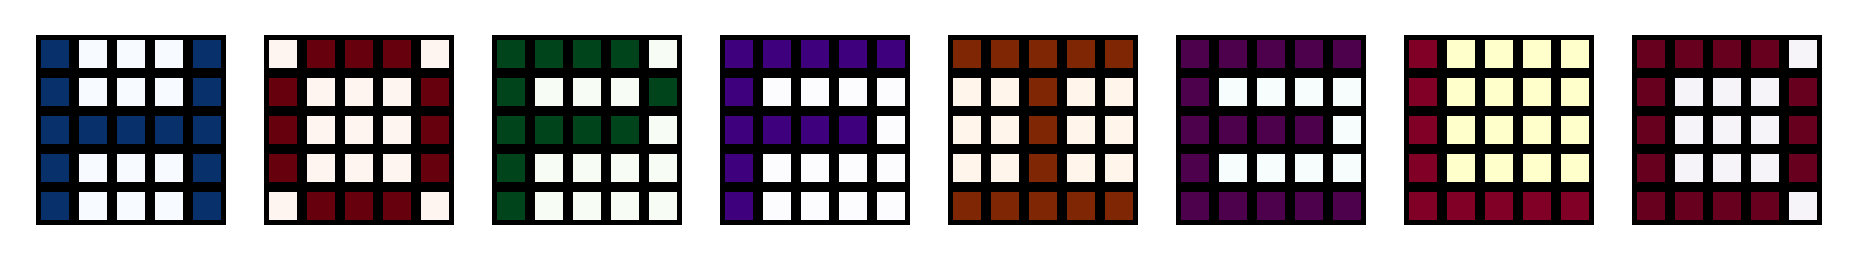

In [5]:
# Un cmap distinto por cada una de las 8 letras de HOPFIELD
color_cmaps = ['Blues', 'Reds', 'Greens', 'Purples',
               'Oranges', 'BuPu', 'YlOrRd', 'PuRd']
print_letters_line(word_letters, cmaps=color_cmaps)